In [1]:
#Librerias a emplear
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Ejercicio de práctica - Distribución binomial

**Contexto:**
Estás optimizando el motor gráfico de una experiencia de Realidad Virtual que debe correr a **60 FPS** (cuadros por segundo) para evitar mareos en el usuario. Tras unas pruebas de estrés, determinas que la probabilidad de que el motor "deje caer" (no renderice a tiempo) un cuadro individual es del **1.5% ($p=0.015$)**.

Durante una cinemática crítica de 10 segundos, el motor intentará renderizar **600 cuadros ($n=600$)**.

---

### Misiones del Laboratorio:
1.  **Probabilidad Puntual:** Calcula la probabilidad de perder exactamente 10 cuadros.
2.  **Análisis de Fallo:** La experiencia se arruina si se pierden más de 15 cuadros ($P(X > 15)$). ¿Cuál es la probabilidad de que la cinemática falle?

In [2]:
x = 10 #Numero de ensayos exitosos
n = 600 #Numero de ensayos
p = 0.015 #Probabilidad de éxito

prob_binomial = binom.pmf(x,n,p)

print(f'La probabilidad binomial para {x} ensayos exitosos es: {prob_binomial:4f}')

La probabilidad binomial para 10 ensayos exitosos es: 0.119479


In [3]:
x=15

prob_binomial = binom.cdf(x,n,p)
print(f'El resultado de la probabilidad binomial es de :{prob_binomial:4f}')

#Cómo es al menos cuatro, calculo la probabilidad complementaria
prob_complementaria = 1 - prob_binomial
print(f'La probabilidad de obtener una perdida de {x+1} cuadros es de: {prob_complementaria:4f}')

El resultado de la probabilidad binomial es de :0.978837
La probabilidad de obtener una perdida de 16 cuadros es de: 0.021163


<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5684/2675142224.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_title('CDF: Probabilidad Acumulada $P(X \leq k)$')


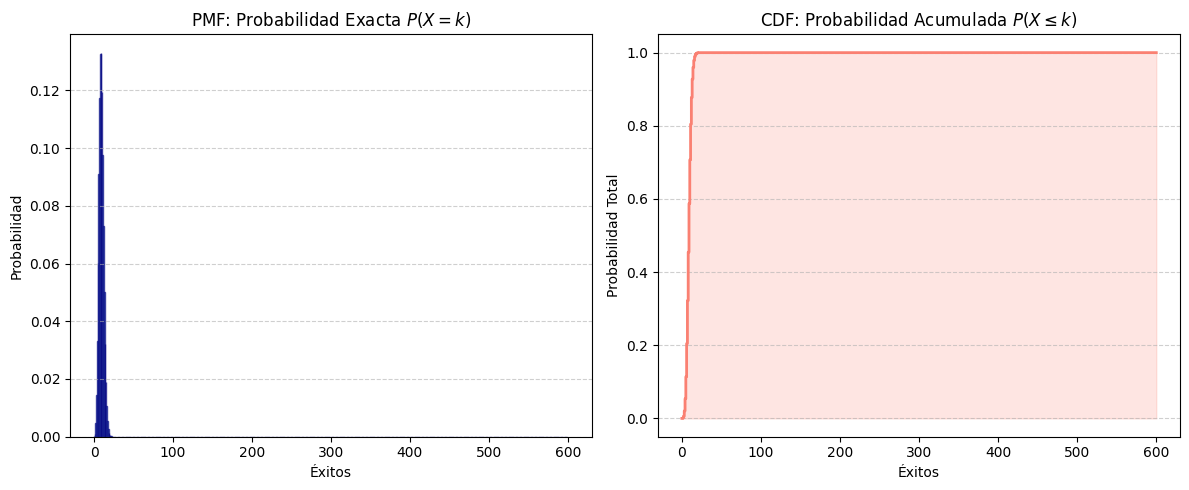

In [ ]:
# Parámetros
n, p = 600, 0.015
x = np.arange(0, n + 1)

# Cálculos
pmf_values = binom.pmf(x, n, p)
cdf_values = binom.cdf(x, n, p)

# Crear la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1: PMF (Probabilidad de cada punto exacto)
ax1.bar(x, pmf_values, color='skyblue', edgecolor='navy', alpha=0.7)
ax1.set_title('PMF: Probabilidad Exacta $P(X=k)$')
ax1.set_xlabel('Éxitos')
ax1.set_ylabel('Probabilidad')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Gráfica 2: CDF (Probabilidad acumulada "hasta" el punto)
ax2.step(x, cdf_values, where='post', color='salmon', linewidth=2)
ax2.fill_between(x, cdf_values, step="post", alpha=0.2, color='salmon')
ax2.set_title('CDF: Probabilidad Acumulada $P(X \leq k)$')
ax2.set_xlabel('Éxitos')
ax2.set_ylabel('Probabilidad Total')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##Medidas de tendencia central - Distribución binomial

* **Valor Esperado (Media):** Representa el promedio a largo plazo.
$$E[X] = \mu = n \cdot p$$

* **Varianza:** Mide la dispersión o "volatilidad" respecto a la media.
$$Var(X) = \sigma^2 = n \cdot p \cdot (1 - p)$$

* **Desviación Estándar:** Es la métrica física (en las mismas unidades que los datos).
$$\sigma = \sqrt{n \cdot p \cdot (1 - p)}$$

In [4]:
#Cálculo de la media
media = n*p
print(f'La media de la distribución es: {media}')

#Cálculo de la varianza
varianza = n*p*(1-p)
print(f'La varianza de la distribución es: {varianza}')

#Cálculo desviasión estandar
desviacion_estandar = np.sqrt(varianza)
print(f'La desviación estandar de la distribución es: {desviacion_estandar: 4f}')


La media de la distribución es: 9.0
La varianza de la distribución es: 8.865
La desviación estandar de la distribución es:  2.977415


##Distribución de Poisson

* La variable aleatoria $x$ es el número de ocurrencias de un evento en algún intervalo.
* Las ocurrencias deben ser aleatorias.
* Las ocurrencias deben ser independientes entre sí.
* Las ocurrencias deben estar uniformemente distribuidas a lo largo del intervalo utilizado.

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

* $e \approx 2.71828$
* $\lambda$: Número medio de ocurrencias del evento en los intervalos.

### Análisis de Nacimientos: NYU-Langone Medical Center

En un año reciente, el **NYU-Langone Medical Center** registró un total de 4221 nacimientos.

**Problema:**
1. Encuentre el número medio de nacimientos por día ($\lambda$).
2. Utilice ese resultado para encontrar la probabilidad de que en un día determinado haya exactamente 15 nacimientos, es decir, $P(X=15)$.
3. ¿Parece probable que en un día dado haya exactamente 15 nacimientos?

In [7]:
lambda_poisson = 4221/365
k = 15


prob_poisson = poisson.pmf(k,lambda_poisson)
print(f'La probabilidad Poisson para {k} nacimientos por día es de: {prob_poisson: 4f}')

prob_acum_poisson = poisson.cdf(k,lambda_poisson)
print(f'La probabilidad acumulada para {k} nacimientos por día es de: {prob_acum_poisson: 4f}')

print(f'La media de nacimientos por día es de: {lambda_poisson:4f}')


La probabilidad Poisson para 15 nacimientos por día es de:  0.064267
La probabilidad acumulada para 15 nacimientos por día es de:  0.874197
La media de nacimientos por día es de: 11.564384


## Distribuciones normales - Estandarizadas

* **Concepto Central:** Es la distribución "molde". Se caracteriza por tener una media $\mu = 0$ y una desviación estándar $\sigma = 1$.

* **Características Geométricas:**
  * Simetría perfecta respecto al eje vertical ($Z = 0$).
  * El área total bajo la curva es exactamente 1 (o 100%).
  * Puntos de inflexión en $Z = -1$ y $Z = 1$.

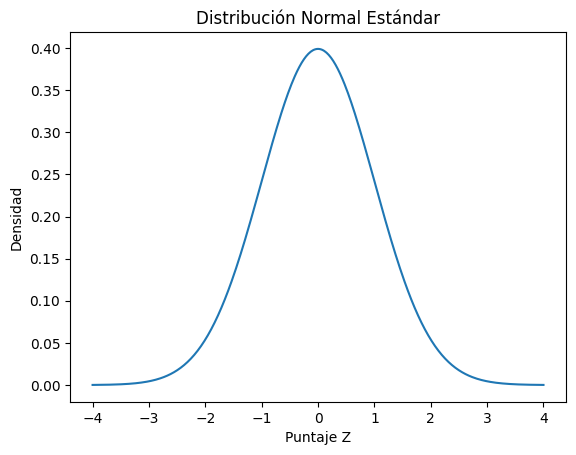

In [8]:
# Crear datos para el eje X
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1) # Función de densidad

plt.plot(x, y)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.show()

###Ejercicio #1
Para hallar $P(Z < 1.96)$, usamos la función de distribución acumulada (CDF)

In [10]:
z = 1.96
prob_normal = norm.cdf(z)
print(f"La probabilidad acumulada para Z={z} es: {prob_normal:.4f}")

La probabilidad acumulada para Z=1.96 es: 0.9750


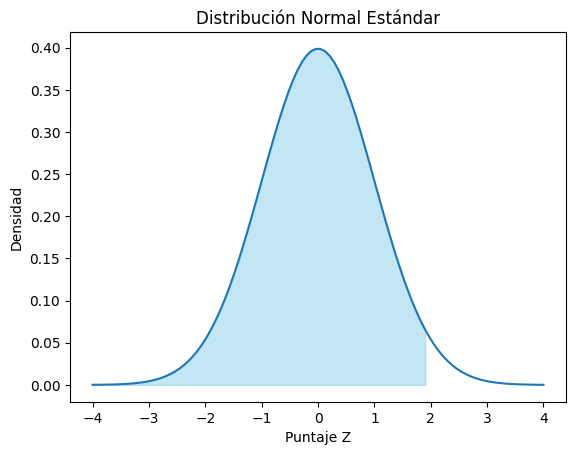

In [ ]:
# Crear datos para el eje X
x = np.linspace(-4, 4, 100)
y = norm.pdf(x, 0, 1) # Función de densidad

plt.plot(x, y)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.fill_between(x, y, where=(x < z), color='skyblue', alpha=0.5)
plt.show()

##Ejercicio #2

Si sabemos que el $90\%$ de nuestros datos deben cumplir un criterio, ¿cuál es el valor $Z$ límite? Se usa la Función de Puntos Porcentuales (PPF).

PPF:(Percent Point Function) es una función de Python en la biblioteca SciPy que calcula la inversa de la función de distribución acumulativa (CDF) de una distribución normal.

In [11]:
# Calcular el valor Z que acumula el 90% (0.90) del área
area_objetivo = 0.90 #Probabilidad del problema
z_limite = norm.ppf(area_objetivo)
print(f"El valor Z para el percentil 90 es: {z_limite:.4f}")

El valor Z para el percentil 90 es: 1.2816


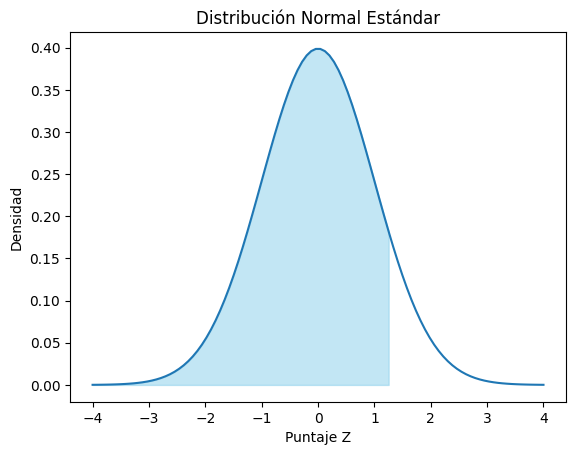

In [12]:
# Crear datos para el eje X
x = np.linspace(-4, 4, 100)
y = norm.pdf(x, 0, 1) # Función de densidad

plt.plot(x, y)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.fill_between(x, y, where=(x < 1.2816), color='skyblue', alpha=0.5)
plt.show()

###Ejercicio #3
Si queremos saber la probabilidad entre dos puntos $P(1< Z < 1.96)$, empleamos una diferencia entre puntos.

In [ ]:
# Probabilidad entre dos puntos: P(1 < Z < 1.96)
z_inf = 1
z_sup = 1.96
area_entre = norm.cdf(z_sup) - norm.cdf(z_inf)
print(f"El área entre {z_inf} y {z_sup} es: {area_entre:.4f}")

El área entre 1 y 1.96 es: 0.1337


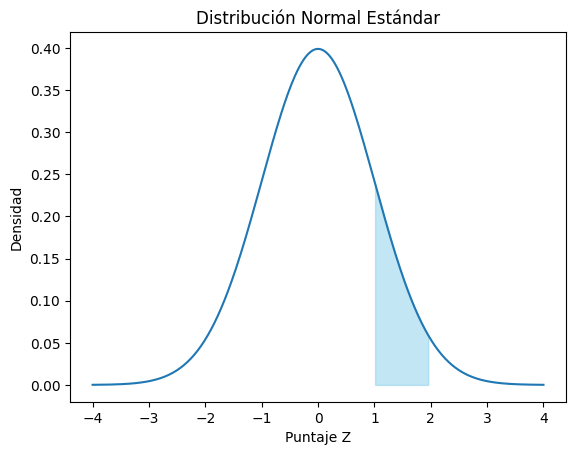

In [ ]:
# Crear datos para el eje X
x = np.linspace(-4, 4, 400)
y = norm.pdf(x, 0, 1)

plt.plot(x, y)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")

# Se deben usar paréntesis y el operador & para condiciones compuestas en arreglos
plt.fill_between(x, y, where=(x >= 1) & (x <= 1.96), color='skyblue', alpha=0.5)

plt.show()

##Distribución normal - No estandarizada

En el entorno industrial y tecnológico, los datos tienen dimensiones físicas reales (segundos, milímetros, píxeles, voltios).

*  La media ya no es cero: $\mu \neq 0$
*  La desviación ya no es uno: $\sigma\neq 1$.

**El Problema**: ¿Cómo aplicamos la teoría estándar a nuestras variables reales ($X$)?

**La Solución:** "Traduciendo" la variable real $X$ al lenguaje universal de $Z$.

**Ecuación Fundamental de Estandarización**:$$Z = \frac{X - \mu}{\sigma}$$

Planteamiento: En una línea de ensamblaje automatizada, el tiempo para soldar un componente se distribuye normalmente con $\mu = 45$ segundos y $\sigma = 3.2$ segundos.

Pregunta Reto: ¿Cuál es la probabilidad de que una pieza tarde más de $50$ segundos en soldarse (creando un cuello de botella)?

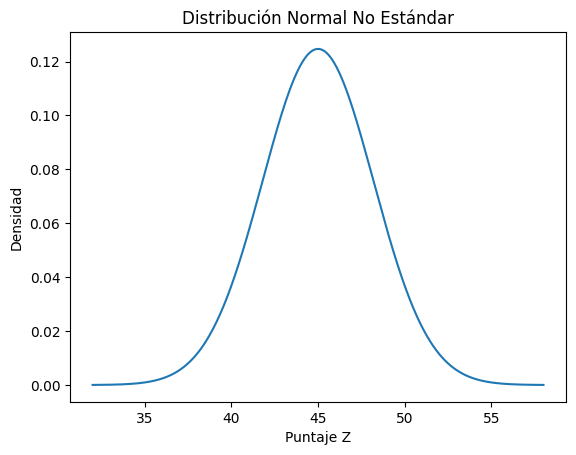

In [ ]:
x = np.linspace(32, 58, 800) #Se usa la regla de media (más o menos)4*Desv_est
y = norm.pdf(x, 45, 3.2)

plt.plot(x, y)
plt.title("Distribución Normal No Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.show()

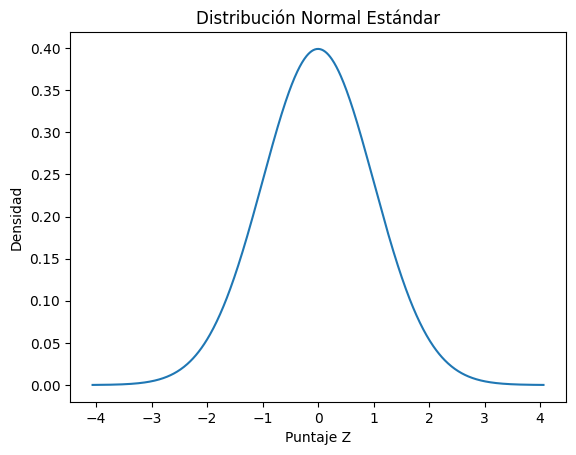

In [ ]:
# Datos originales
x = np.linspace(32, 58, 800)
mu = 45
sigma = 3.2

#Se estandarizan los valores de x, a partir del cálculo de puntuaciones
z = (x - mu) / sigma

#Se calcula la distribución normal con media = 0 y desv_est = 1
y_estandar = norm.pdf(z, 0, 1)

#Se realiza el gráfico
plt.plot(z, y_estandar)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.show()

In [ ]:
mu_ind = 45
sigma_ind = 3.2
x_critico = 50

# Método 1: Estandarizando manualmente
z_industrial = (x_critico - mu_ind) / sigma_ind
prob_exceso = 1 - norm.cdf(z_industrial)

print(f"El valor de Z es {z_industrial}")
print(f"La probabilidad de que tarde más de {x_critico} segundos es: {prob_exceso}")

El valor de Z es 1.5625
La probabilidad de que tarde más de 50 segundos es: 0.059085122932667544


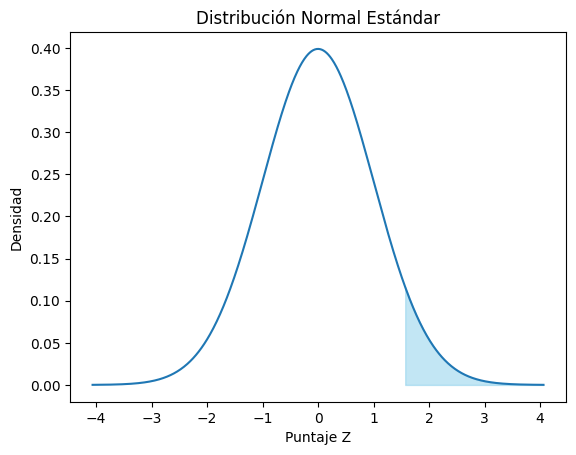

In [ ]:
# Datos originales
x = np.linspace(32, 58, 800)
mu = 45
sigma = 3.2

#Se estandarizan los valores de x, a partir del cálculo de puntuaciones
z = (x - mu) / sigma

#Se calcula la distribución normal con media = 0 y desv_est = 1
y_estandar = norm.pdf(z, 0, 1)

#Se realiza el gráfico
plt.plot(z, y_estandar)
plt.title("Distribución Normal Estándar")
plt.xlabel("Puntaje Z")
plt.ylabel("Densidad")
plt.fill_between(z, y_estandar, where=(z >= 1.5625), color='skyblue', alpha=0.5)
plt.show()

##